# Customer Churn Analysis and Prediction  
### Machine Learning Internship Project – SaiKet Systems  

**Developed by:** Prasanna G

This project focuses on analyzing customer churn in a telecommunications company and building a machine learning model to predict customer churn.

## Objectives:
- Analyze customer data
- Build a predictive model
- Provide business insights to reduce churn

## Task 1: Data Preparation

In this step, we:
- Load the dataset
- Handle missing values
- Encode categorical variables

In [17]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

df.head()

print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [3]:
# Handle missing values
df.replace(" ", np.nan, inplace=True)
df.dropna(inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    if col != "Churn":   # 👈 ADD THIS LINE
        df[col] = le.fit_transform(df[col])

# Encode target separately
df["Churn"] = le.fit_transform(df["Churn"])

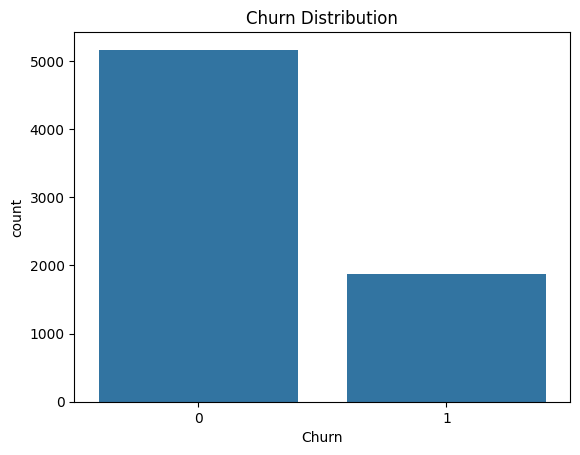

In [12]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

## Task 3: Feature Selection

Feature importance is calculated using Random Forest on the dataset to identify key factors influencing churn.

Note: This step is performed for analysis purposes.

In [14]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("Churn", axis=1)
y = df["Churn"]

model = RandomForestClassifier()
model.fit(X, y)

import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

TotalCharges        0.153586
MonthlyCharges      0.148541
tenure              0.140144
customerID          0.132494
Contract            0.075202
TechSupport         0.042660
PaymentMethod       0.042431
OnlineSecurity      0.041492
InternetService     0.026178
OnlineBackup        0.025821
gender              0.022920
PaperlessBilling    0.021589
DeviceProtection    0.020264
MultipleLines       0.019441
Partner             0.018905
SeniorCitizen       0.018118
Dependents          0.016151
StreamingMovies     0.014929
StreamingTV         0.014491
PhoneService        0.004644
dtype: float64

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'TotalCharges'),
  Text(1, 0, 'MonthlyCharges'),
  Text(2, 0, 'tenure'),
  Text(3, 0, 'customerID'),
  Text(4, 0, 'Contract'),
  Text(5, 0, 'TechSupport'),
  Text(6, 0, 'PaymentMethod'),
  Text(7, 0, 'OnlineSecurity'),
  Text(8, 0, 'InternetService'),
  Text(9, 0, 'OnlineBackup')])

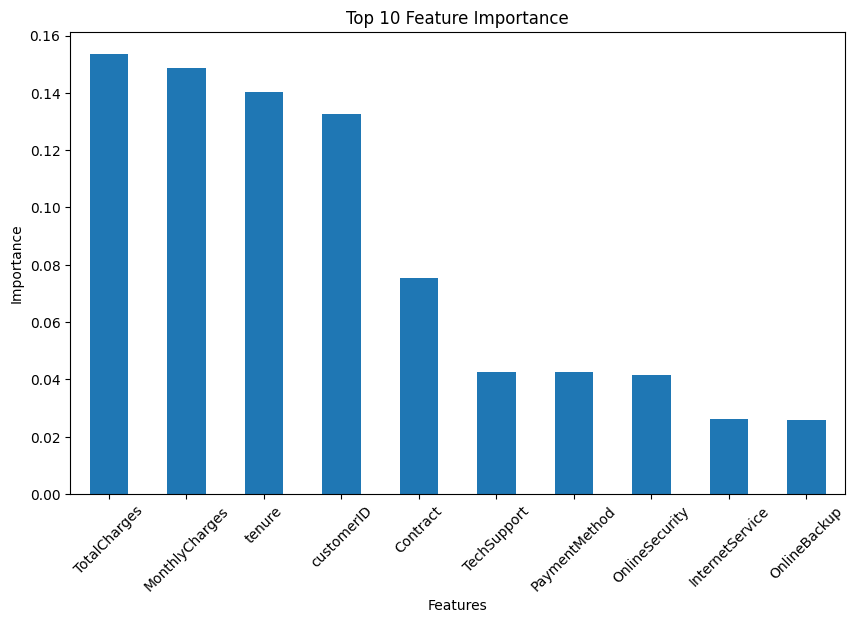

In [29]:
import matplotlib.pyplot as plt

# Sort values
feature_importance_sorted = feature_importance.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
feature_importance_sorted.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

## Task 2: Train-Test Split

We split the dataset into:
- 80% Training Data
- 20% Testing Data

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((5625, 20), (1407, 20))

## Task 4: Model Selection

We choose Random Forest Classifier as it performs well for classification problems and handles feature importance effectively.

## Task 5: Model Training

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7874911158493249


c:\Users\prasa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Task 6: Model Evaluation

We evaluate the model using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [25]:
rf_pred = model.predict(X_test)

print("===== Model Comparison =====")
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:\n", classification_report(y_test, rf_pred))

===== Model Comparison =====
Random Forest Accuracy: 0.7846481876332623
Logistic Regression Accuracy: 0.7874911158493249

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



Text(0, 0.5, 'Accuracy')

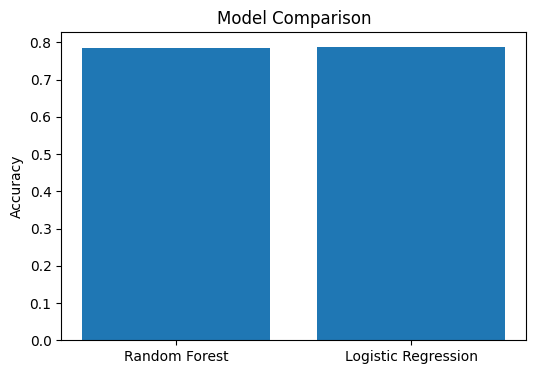

In [28]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Logistic Regression"]
scores = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, lr_pred)
]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")

### Model Comparison Result

Random Forest performs better than Logistic Regression, making it the preferred model for this problem.

### Confusion Matrix Visualization

The heatmap below visualizes the performance of the Random Forest model by comparing predicted and actual values.

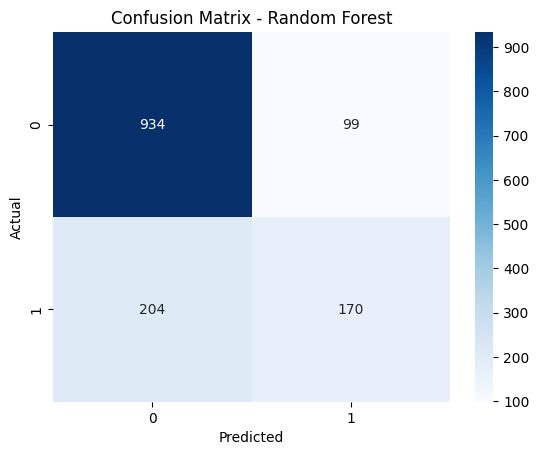

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Business Insights

- Customers with higher monthly charges are more likely to churn.
- Customers with longer tenure are less likely to churn.
- Customers with month-to-month contracts show higher churn rates.

## Recommendations

- Offer discounts to high-risk customers
- Encourage long-term contracts
- Improve customer engagement strategies

## Conclusion

The model successfully predicts customer churn and can help businesses take proactive measures to retain customers.